In [32]:
import pandas as pd 
import seaborn as sns
import pathlib as pl
import matplotlib.pyplot as plt
from adjustText import adjust_text 

In [33]:
root_path = pl.Path.cwd().parent.parent
data_path = root_path / "data" / "intermed" / "googleplaystore_clean.csv"

In [34]:
data = pd.read_csv(data_path)
data.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Days_Since_Update
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,213
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Art & Design,2018-01-15,2.0.0,4.0.3 and up,205
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Pretend Play,2018-01-15,2.0.0,4.0.3 and up,205
3,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,7
4,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,61


In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9339 entries, 0 to 9338
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9339 non-null   int64  
 1   App                9339 non-null   str    
 2   Category           9339 non-null   str    
 3   Rating             9339 non-null   float64
 4   Reviews            9339 non-null   int64  
 5   Size               9339 non-null   str    
 6   Installs           9339 non-null   float64
 7   Type               9339 non-null   str    
 8   Price              9339 non-null   str    
 9   Content Rating     9339 non-null   str    
 10  Genres             9339 non-null   str    
 11  Last Updated       9339 non-null   str    
 12  Current Ver        9335 non-null   str    
 13  Android Ver        9337 non-null   str    
 14  Days_Since_Update  9339 non-null   int64  
dtypes: float64(2), int64(3), str(10)
memory usage: 1.1 MB


In [36]:
category_analysis = data.groupby("Category").agg({
    "Installs": "mean",
    "App": "count"
})
category_analysis = category_analysis.rename(columns={"App": "App Count", "Installs": "Average Installs"})
category_analysis = category_analysis.sort_values("Average Installs", ascending=False).head(10)

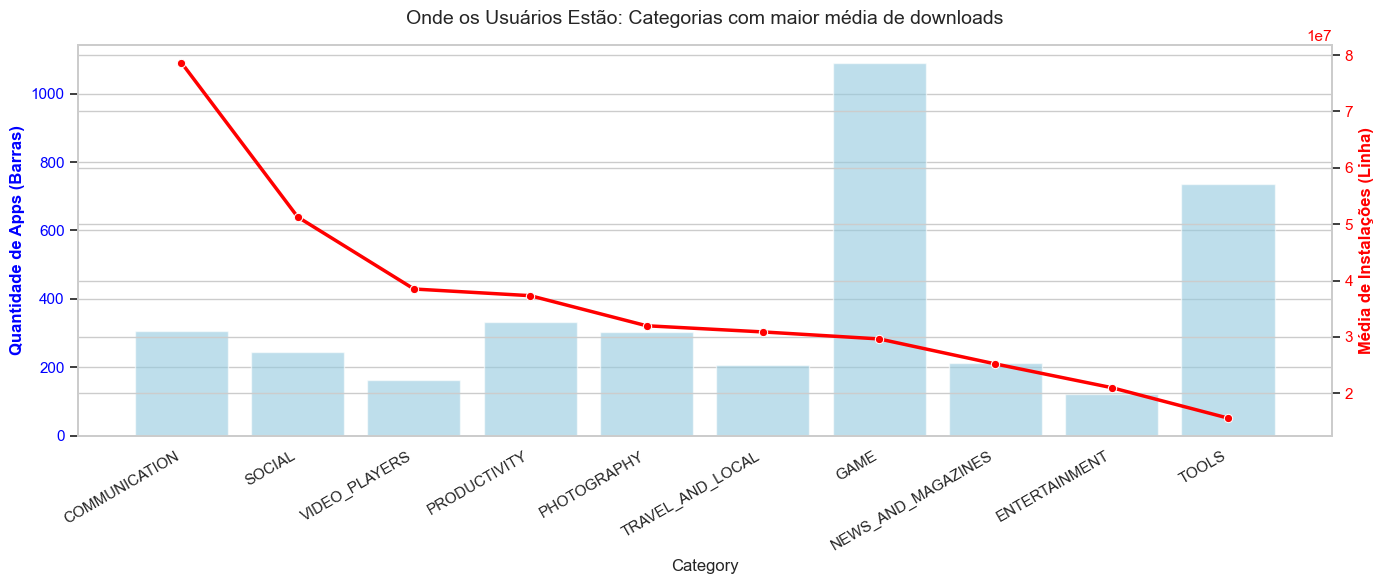

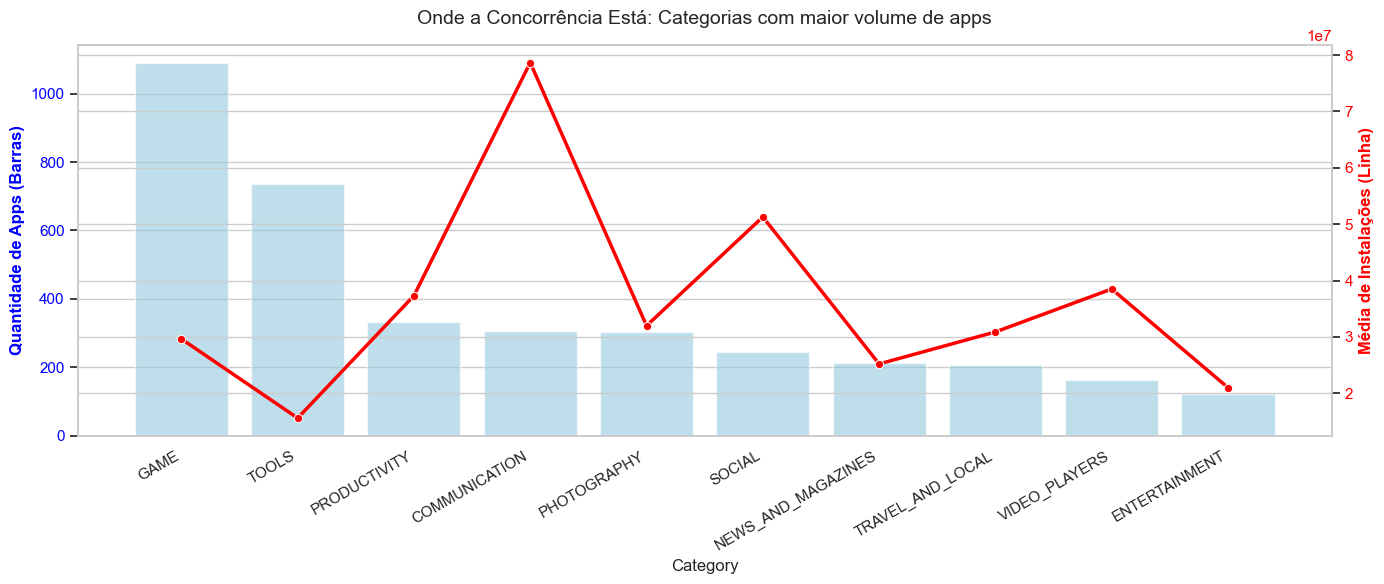

In [ ]:


plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

df_demanda = category_analysis.sort_values('Average Installs', ascending=False).head(10)


ax1 = sns.barplot(x='Category', y='App Count', data=df_demanda, color='skyblue', alpha=0.6)
ax1.set_ylabel('Quantidade de Apps (Barras)', color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Onde os Usuários Estão: Categorias com maior média de downloads', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')

# Eixo Gêmeo: Média de Instalações
ax1_twin = ax1.twinx()
sns.lineplot(x='Category', y='Average Installs', data=df_demanda, ax=ax1_twin, marker='o', color='red', linewidth=2.5)
ax1_twin.set_ylabel('Média de Instalações (Linha)', color='red', fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

df_oferta = category_analysis.sort_values('App Count', ascending=False).head(10)

ax2 = sns.barplot(x='Category', y='App Count', data=df_oferta, color='skyblue', alpha=0.6)
ax2.set_ylabel('Quantidade de Apps (Barras)', color='blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_title('Onde a Concorrência Está: Categorias com maior volume de apps', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')

ax2_twin = ax2.twinx()
sns.lineplot(x='Category', y='Average Installs', data=df_oferta, ax=ax2_twin, marker='o', color='red', linewidth=2.5)
ax2_twin.set_ylabel('Média de Instalações (Linha)', color='red', fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

In [38]:
rated_data = data[data["Rating"].notna()]

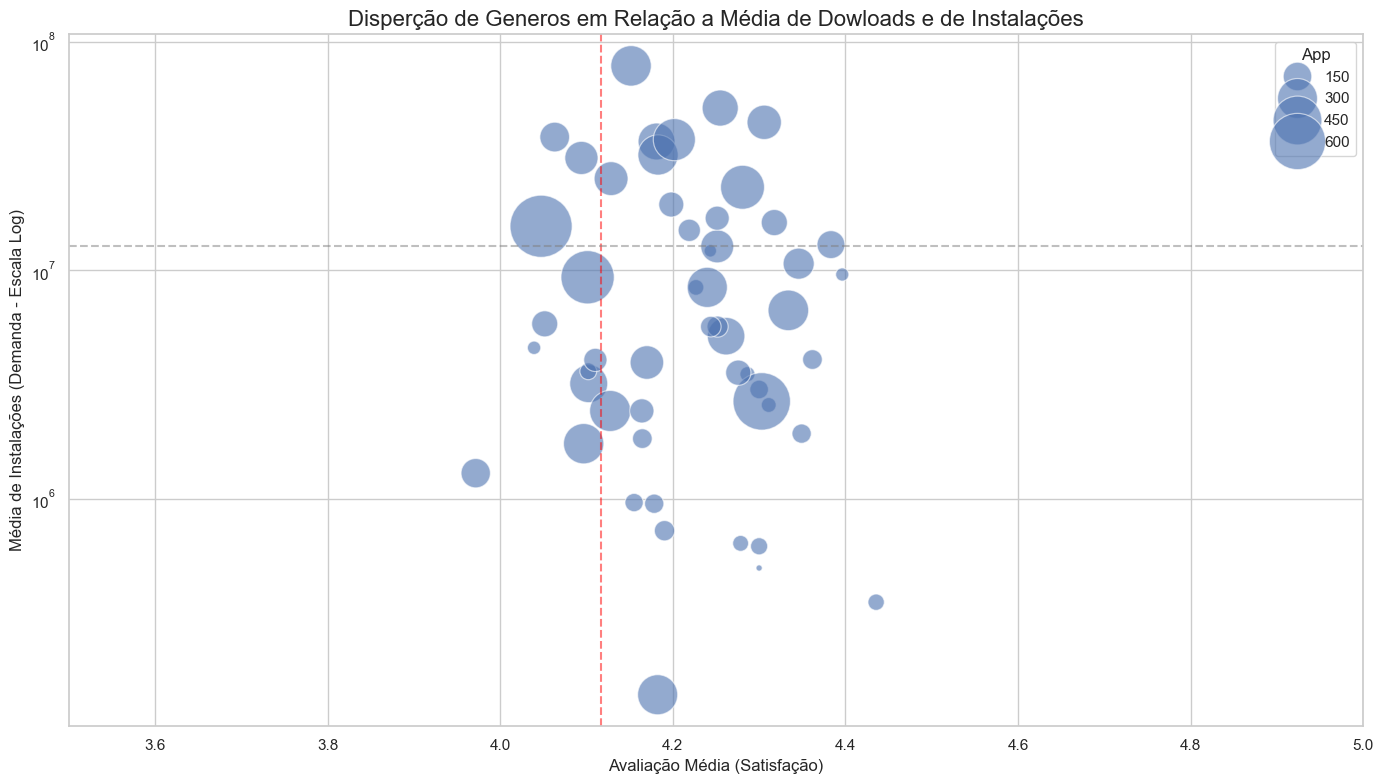

In [ ]:

gp_data = data.groupby("Genres").agg({
    "Rating": "mean", 
    "Installs": "mean",
    "App":"count"
}).reset_index()

limite_rating = gp_data['Rating'].quantile(0.20)
limite_installs = gp_data['Installs'].quantile(0.70)


plt.figure(figsize=(14, 8))



ax = sns.scatterplot(data=gp_data, x='Rating', y='Installs',size="App",  
    sizes=(20, 2000), 
    alpha=0.6, s=120)


plt.yscale('log')


plt.axvline(limite_rating, color='red', linestyle='--', alpha=0.5) 
plt.axhline(limite_installs, color='gray', linestyle='--', alpha=0.5)


plt.title('Disperção de Generos em Relação a Média de Dowloads e de Instalações', fontsize=16)
plt.xlabel('Avaliação Média (Satisfação)', fontsize=12)
plt.ylabel('Média de Instalações (Demanda - Escala Log)', fontsize=12)
plt.xlim(3.5, 5)
plt.tight_layout()
plt.show()

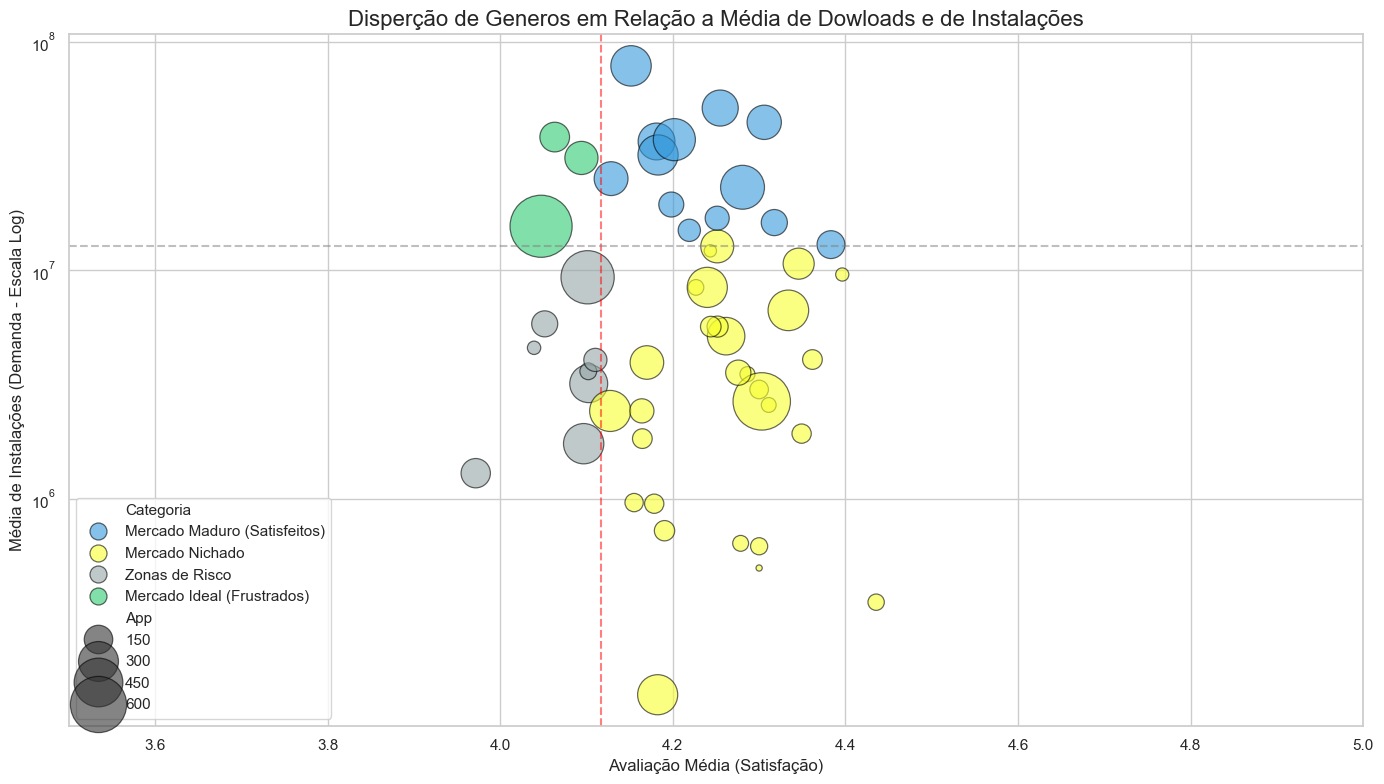

In [ ]:
def classificar_oportunidade(row):

    if row['Installs'] >= limite_installs and row['Rating'] < limite_rating:
        return 'Mercado Ideal (Frustrados)'

    elif row['Installs'] >= limite_installs and row['Rating'] >= limite_rating:
        return 'Mercado Maduro (Satisfeitos)'
    elif row['Installs'] < limite_installs and row['Rating'] > limite_rating:
        return 'Mercado Nichado'
    else:
        return 'Zonas de Risco'

gp_data['Categoria'] = gp_data.apply(classificar_oportunidade, axis=1)

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

cores = {
    'Mercado Ideal (Frustrados)': '#2ecc71',      
    'Mercado Maduro (Satisfeitos)': '#3498db',   
    'Zonas de Risco': '#95a5a6',
    'Mercado Nichado':'#f8ff2f'         
}

ax = sns.scatterplot(
    data=gp_data, 
    x='Rating', 
    y='Installs', 
    hue='Categoria',
    palette=cores,
    size="App",      
    sizes=(20, 2000), 
    alpha=0.6,
    s=150, 
    edgecolor='black' 
)

plt.yscale('log')

plt.axvline(limite_rating, color='red', linestyle='--', alpha=0.5) 
plt.axhline(limite_installs, color='gray', linestyle='--', alpha=0.5)

texts = [] 

plt.title('Disperção de Generos em Relação a Média de Dowloads e de Instalações', fontsize=16)
plt.xlabel('Avaliação Média (Satisfação)', fontsize=12)
plt.ylabel('Média de Instalações (Demanda - Escala Log)', fontsize=12)
plt.xlim(3.5, 5)
plt.tight_layout()
plt.show()

Categoria
Mercado Nichado                 29
Mercado Maduro (Satisfeitos)    13
Zonas de Risco                   8
Mercado Ideal (Frustrados)       3
Name: count, dtype: int64

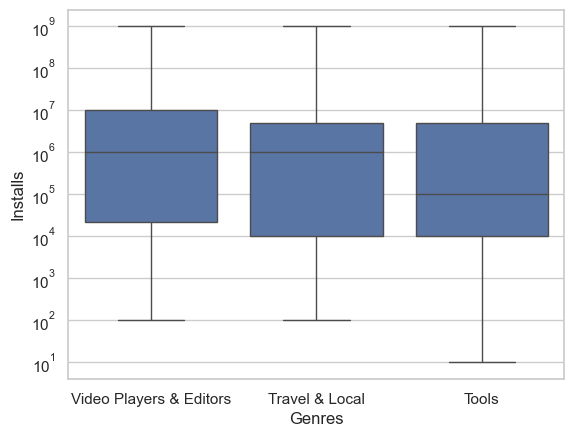

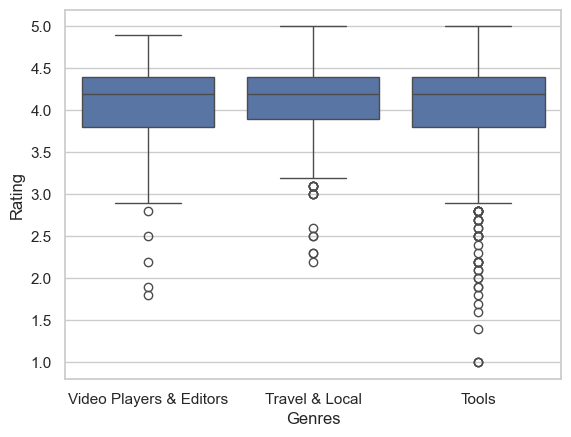

In [ ]:
display(gp_data["Categoria"].value_counts())
green_genres = gp_data[gp_data["Categoria"] == "Mercado Ideal (Frustrados)"]["Genres"].unique()

sns.boxplot(data=data[data["Genres"].isin(green_genres)],x="Genres",y="Installs",log_scale=True)
plt.show()
sns.boxplot(data=data[data["Genres"].isin(green_genres)],x="Genres",y="Rating")
plt.show()

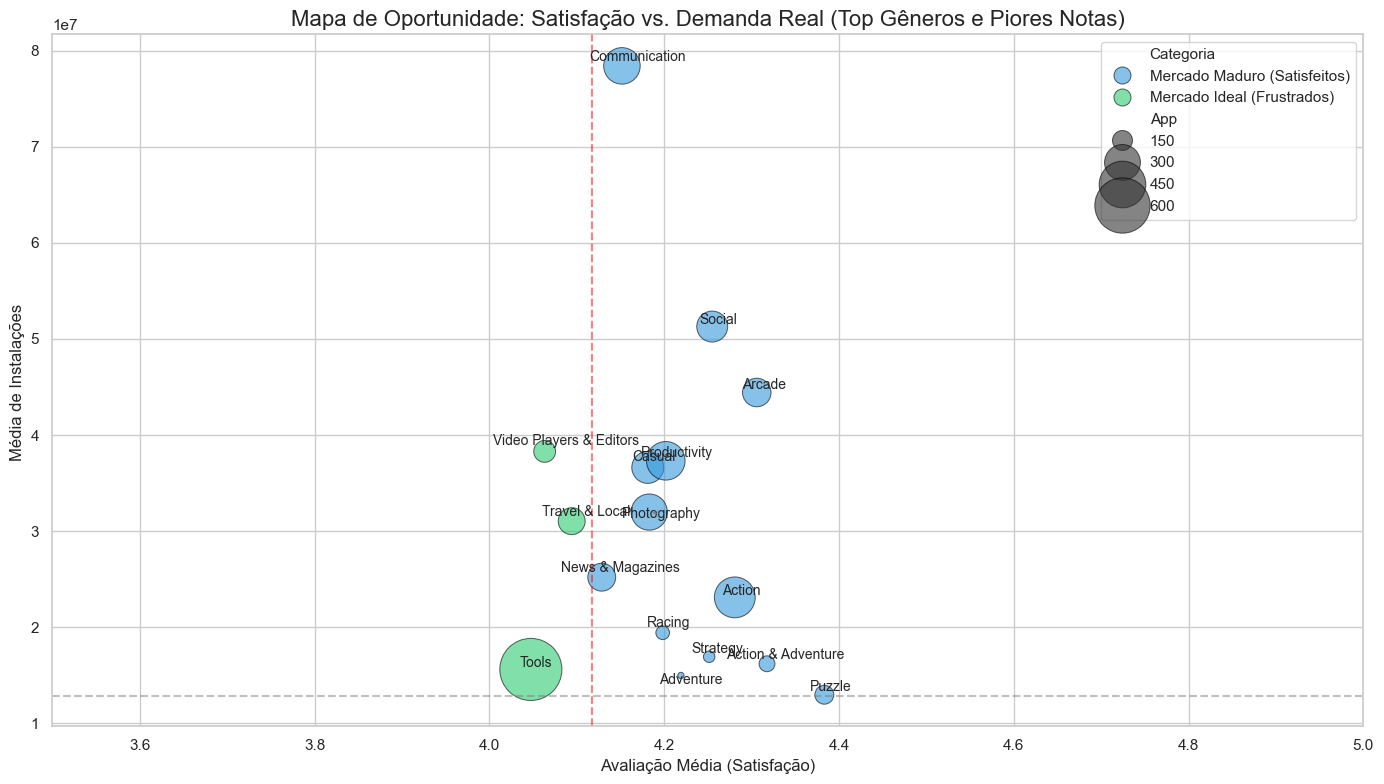

In [ ]:

gp_data = gp_data[(gp_data.Installs > limite_installs)]
gp_data = gp_data.reset_index(drop=True)

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

ax = sns.scatterplot(
    data=gp_data, 
    x='Rating', 
    y='Installs', 
    hue='Categoria', 
    palette=cores,
    size="App",      
    sizes=(20, 2000), 
    alpha=0.6,
    s=150, 
    edgecolor='black' 
)

plt.axvline(limite_rating, color='red', linestyle='--', alpha=0.5) 
plt.axhline(limite_installs, color='gray', linestyle='--', alpha=0.5)

texts = [] 

for i in range(gp_data.shape[0]):

    rating_val = gp_data.Rating[i]
    installs_val = gp_data.Installs[i]
    genre_name = gp_data.Genres[i]
    

    texts.append(plt.text(rating_val, installs_val, genre_name, fontsize=10))

adjust_text(
    texts, 
    only_move={'points':'y', 'text':'xy'}, 
    force_points=2.0,     
    force_text=2.5,       
    expand_points=(2, 2), 
    expand_text=(2.5, 2.5), 
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5, alpha=1) 
)

plt.title('Mapa de Oportunidade: Satisfação vs. Demanda Real (Top Gêneros e Piores Notas)', fontsize=16)
plt.xlabel('Avaliação Média (Satisfação)', fontsize=12)
plt.ylabel('Média de Instalações ', fontsize=12)
plt.xlim(3.5, 5)
plt.tight_layout()
plt.show()